In [3]:
import os
import pprint
import json
import statistics as s
import copy as c

In [4]:
import math as m
from scipy import special as s
from matplotlib import pyplot as plt
import numpy as np

In [5]:
path = 'Desktop'
files = os.listdir(path)
files.sort()
# files

In [6]:
def readfile(path,file):
    txt_file = open((os.path.join(path,file)) , 'r')
    line = 'a'
    raw_data = []
    while len(line) > 0:
        line = txt_file.readline()
        if len(line) > 0:
            elements = line.split()
#             print(elements) for debugging only
            raw_data.append(elements[2:])
    txt_file.close()
    return raw_data

In [7]:
ques_1 = readfile(path,'oxide.txt')
ques_1b = readfile(path,'ox_thick_1150.txt')
ques_1c = readfile(path,'ox_thick_1150_wet.txt')


In [8]:
time = [float(ques_1[i][0]) for i in range(len(ques_1))]

ox_900 = [float(ques_1[i][1]) for i in range(len(ques_1))]
ox_1150 = [float(ques_1b[i][1]) for i in range(len(ques_1b))]
ox_1150_wet = [float(ques_1c[i][1]) for i in range(len(ques_1c))]

In [13]:
a = 30

l = np.polyfit(time[1:4],ox_900[1:4],1)
lin_900 = [l[0]*i + l[1] for i in time]

p = np.polyfit(time[a:],ox_900[a:],2)
poly_900 = [p[0]*i*i + p[1]*i + p[2] for i in time]

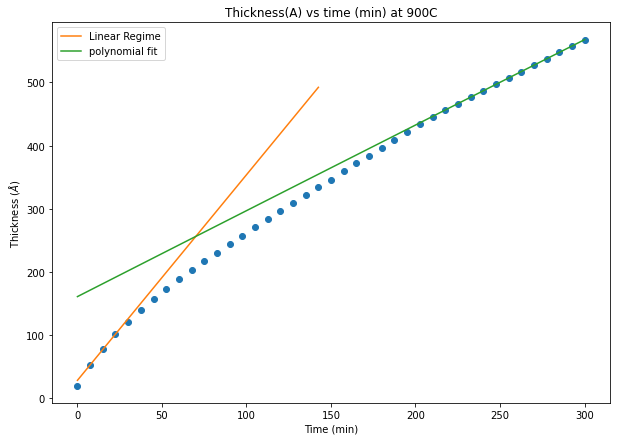

In [15]:
plt.figure(figsize=(10,7))
plt.plot(time,ox_900, marker = 'o', linestyle ='none')
plt.title('Thickness(A) vs time (min) at 900C')
plt.plot(time[:20],lin_900[:20], label='Linear Regime')
plt.plot(time,poly_900, label = 'polynomial fit')
plt.ylabel('Thickness ($\AA$)')
plt.xlabel(r'Time (min)')
plt.legend()

In [11]:
a = 30
b = 3
l = np.polyfit(time[:b],ox_1150[:b],1)
lin_1150 = [l[0]*i + l[1] for i in time]

p = np.polyfit(time[a:],ox_1150[a:],2)
poly_1150 = [p[0]*i*i + p[1]*i + p[2] for i in time]


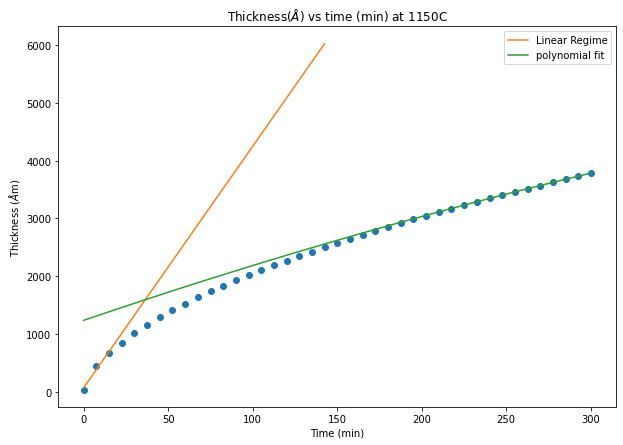

In [17]:
plt.figure(figsize=(10,7))
plt.plot(time,ox_1150, marker = 'o', linestyle ='none')
plt.title('Thickness($\AA$) vs time (min) at 1150C')
plt.plot(time[:20],lin_1150[:20], label='Linear Regime')
plt.plot(time,poly_1150, label = 'polynomial fit')
plt.ylabel('Thickness ($\AA$m)')
plt.xlabel(r'Time (min)')
plt.legend()

In [21]:
a = 30
b = 3
l = np.polyfit(time[:b],ox_1150_wet[:b],1)
lin_1150_wet = [l[0]*i + l[1] for i in time]

p = np.polyfit(time[a:],ox_1150_wet[a:],2)
poly_1150_wet = [p[0]*i*i + p[1]*i + p[2] for i in time]



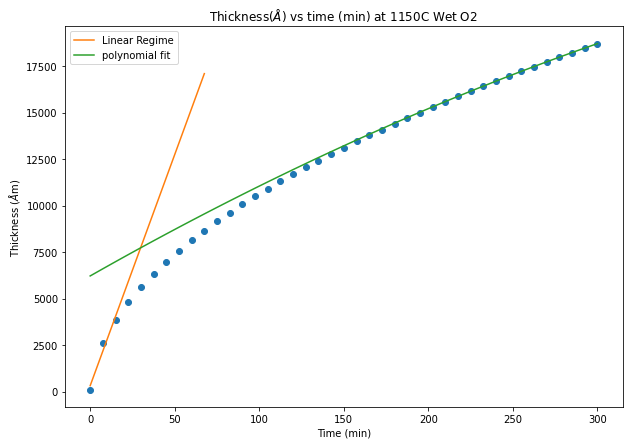

In [24]:
plt.figure(figsize=(10,7))
plt.plot(time,ox_1150_wet, marker = 'o', linestyle ='none')
plt.title('Thickness($\AA$) vs time (min) at 1150C Wet O2')
plt.plot(time[:10],lin_1150_wet[:10], label='Linear Regime')
plt.plot(time,poly_1150_wet, label = 'polynomial fit')
plt.ylabel('Thickness ($\AA$m)')
plt.xlabel(r'Time (min)')
plt.legend()

In [25]:
#thermal budget
k_ev = 8.617*pow(10,-5)
d = 1.1*pow(10,-3)
def budget(T,t):
    time = t*60
    ex = m.exp(-0.89/(k_ev*T))
    diff = d*ex
    return pow(diff*time,0.5)

In [33]:
budget(950,174)

0.014764443691223011

In [32]:
budget(1050,67)

0.015375199873836912

In [30]:
budget(1150,35)

0.017043372265512644